=== Columnas por dataset ===
- Solo en v1 (2): ['Date', 'resultado_operacion_insider']
- Solo en v2 (3): ['Adj Close', 'quarter', 'year']
- En común (13): ['Operacion_insider', 'Ticker', '_qy_date', '_qy_quarter', 'activity_act', 'activity_porc', 'diferencia_cierre_vs_apertura', 'ebitda', 'eps_surprise', 'insider_rating', 'netIncome', 'nombre_holding', 'quarter - year']

=== Dtypes (comunes) ===


/tmp/ipykernel_1458830/4253436673.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(ser, errors="coerce")
/tmp/ipykernel_1458830/4253436673.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")
/tmp/ipykernel_1458830/4253436673.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


,dtype_v1,dtype_v2
Operacion_insider,int64,int64
Ticker,category,category
_qy_date,datetime64[ns],datetime64[ns]
_qy_quarter,int32,int32
activity_act,int64,int64
activity_porc,float64,float64
diferencia_cierre_vs_apertura,float64,float64
ebitda,float64,float64
eps_surprise,float64,float64
insider_rating,float64,float64



=== Porcentaje de nulos (Top 20 por v1 y v2) ===


,v1_pct_null,v2_pct_null
resultado_operacion_insider,0.004138,0.0
Adj Close,0.000000,0.0
Date,0.000000,0.0
Operacion_insider,0.000000,0.0
_qy_date,0.000000,0.0
Ticker,0.000000,0.0
activity_act,0.000000,0.0
activity_porc,0.000000,0.0
diferencia_cierre_vs_apertura,0.000000,0.0
_qy_quarter,0.000000,0.0


,v1_pct_null,v2_pct_null
Adj Close,0.000000,0.0
Date,0.000000,0.0
Operacion_insider,0.000000,0.0
Ticker,0.000000,0.0
_qy_date,0.000000,0.0
_qy_quarter,0.000000,0.0
activity_act,0.000000,0.0
activity_porc,0.000000,0.0
diferencia_cierre_vs_apertura,0.000000,0.0
ebitda,0.000000,0.0



=== Heatmaps de correlación (coolwarm, annot=True) ===


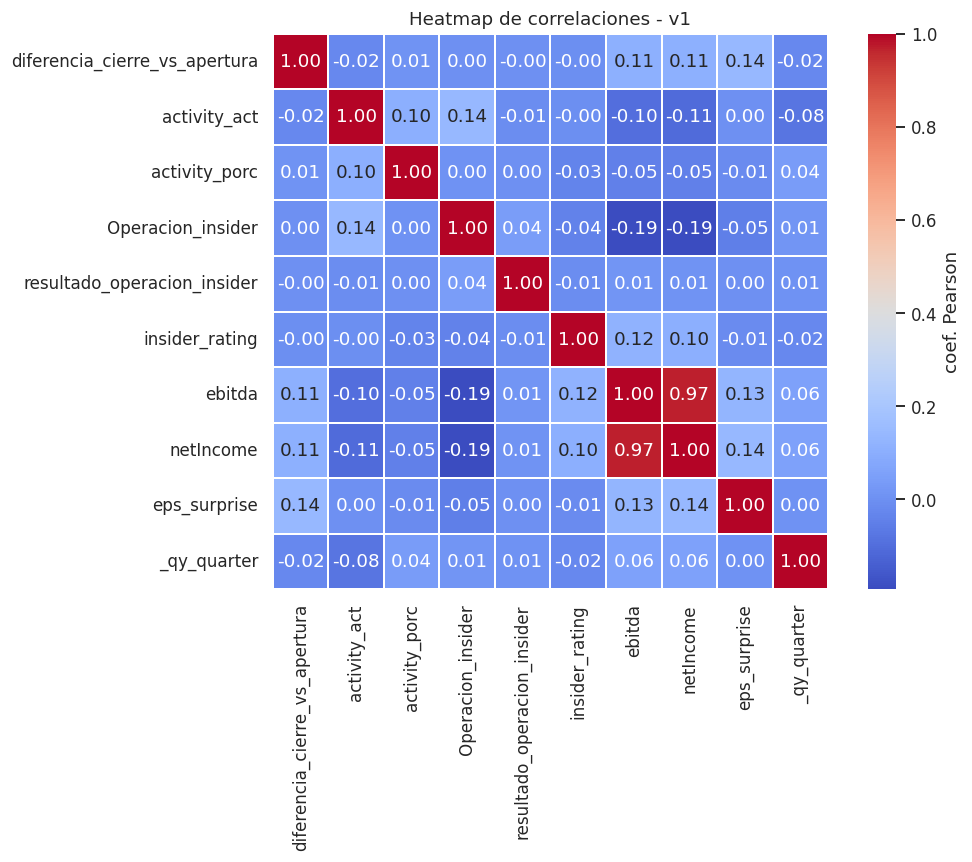

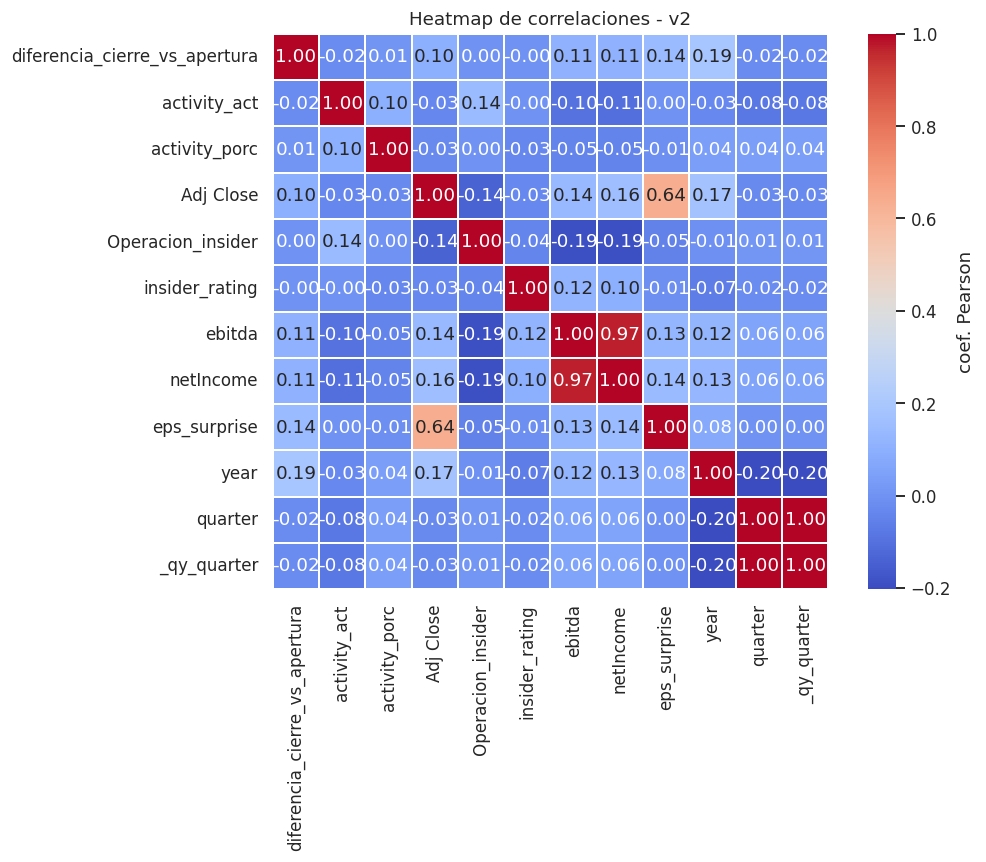

In [6]:
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.tseries.offsets import MonthEnd
from matplotlib.ticker import MaxNLocator
from IPython.display import display

# ---------- Config ----------
PATH_V1 = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep.csv"
PATH_V2 = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep_v2.csv"

NUMERIC_HINT = {
    "diferencia_cierre_vs_apertura","activity_act","activity_porc","Adj Close",
    "Operacion_insider","resultado_operacion_insider","insider_rating",
    "ebitda","netIncome","eps_surprise","year","quarter"
}
CATEG_HINT = {"Ticker","nombre_holding"}

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# ---------- Utils ----------
def parse_date_series(s, dayfirst=True):
    if s is None: return None
    return pd.to_datetime(s, errors="coerce", dayfirst=dayfirst)

def parse_quarter_year_to_date(qy):
    if qy is None: return None
    ser = qy.astype(str)
    dt = pd.to_datetime(ser, errors="coerce")
    mask_nan = dt.isna()
    if mask_nan.any():
        def q_to_date(txt):
            m = re.match(r"Q([1-4])\s+(\d{4})", str(txt))
            if not m: return pd.NaT
            q = int(m.group(1)); y = int(m.group(2))
            month_end = {1:3, 2:6, 3:9, 4:12}[q]
            return pd.Timestamp(year=y, month=month_end, day=1) + MonthEnd(0)
        dt2 = ser[mask_nan].map(q_to_date)
        dt.loc[mask_nan] = dt2
    return dt

def coerce_numeric_cols(df, numeric_hint):
    for c in df.columns:
        if (c in numeric_hint) or (df[c].dtype == object):
            df[c] = pd.to_numeric(df[c], errors="ignore")
    for c in df.select_dtypes(include="object").columns:
        vals = df[c].dropna().astype(str)
        if len(vals) > 0:
            frac_num = (vals.str.match(r"^[-+]?\d*\.?\d+(e[-+]?\d+)?$", case=False)).mean()
            if frac_num >= 0.8:
                df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def corr_numeric(df):
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] == 0: return pd.DataFrame()
    return num.corr(numeric_only=True)

def pct_nulls(df):
    return (df.isna().mean()).sort_values(ascending=False).to_frame("pct_null")

def hist_with_counts(ax, data, bins=40, title=None):
    x = pd.Series(data).dropna().values
    if len(x) == 0:
        ax.set_visible(False); return
    counts, bin_edges, patches = ax.hist(x, bins=bins, edgecolor="black", alpha=0.8)
    for c, patch in zip(counts, patches):
        if c <= 0: continue
        x0 = patch.get_x(); w = patch.get_width(); h = patch.get_height()
        ax.text(x0 + w/2, h, f"{int(c)}", ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("Conteos")
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
    ax.grid(True, axis="y", linestyle=":", linewidth=0.5)
    if title: ax.set_title(title)

# ---------- Carga + armonización ----------
v1 = pd.read_csv(PATH_V1)
v2 = pd.read_csv(PATH_V2)

if "Date" in v1.columns: v1["Date"] = parse_date_series(v1["Date"], dayfirst=True)
if "Date" in v2.columns: v2["Date"] = parse_date_series(v2["Date"], dayfirst=True)

if "quarter - year" in v1.columns:
    v1["_qy_date"] = parse_quarter_year_to_date(v1["quarter - year"])
    v1["_qy_quarter"] = v1["_qy_date"].dt.quarter
if "quarter - year" in v2.columns:
    v2["_qy_date"] = parse_quarter_year_to_date(v2["quarter - year"])
    v2["_qy_quarter"] = v2["_qy_date"].dt.quarter

v1 = coerce_numeric_cols(v1, NUMERIC_HINT)
v2 = coerce_numeric_cols(v2, NUMERIC_HINT)
for c in CATEG_HINT:
    if c in v1.columns: v1[c] = v1[c].astype("category")
    if c in v2.columns: v2[c] = v2[c].astype("category")

# ---------- 1) Diferencia de columnas ----------
cols_v1, cols_v2 = set(v1.columns), set(v2.columns)
only_v1 = sorted(cols_v1 - cols_v2)
only_v2 = sorted(cols_v2 - cols_v1)
common_cols = sorted(cols_v1 & cols_v2)

print("=== Columnas por dataset ===")
print(f"- Solo en v1 ({len(only_v1)}): {only_v1}")
print(f"- Solo en v2 ({len(only_v2)}): {only_v2}")
print(f"- En común ({len(common_cols)}): {common_cols}")

# ---------- 2) Dtypes y nulos ----------
print("\n=== Dtypes (comunes) ===")
dtypes_cmp = pd.DataFrame({
    "dtype_v1": [str(v1[c].dtype) for c in common_cols],
    "dtype_v2": [str(v2[c].dtype) for c in common_cols]
}, index=common_cols)
display(dtypes_cmp)

print("\n=== Porcentaje de nulos (Top 20 por v1 y v2) ===")
nulls_v1 = pct_nulls(v1).rename(columns={"pct_null":"v1_pct_null"})
nulls_v2 = pct_nulls(v2).rename(columns={"pct_null":"v2_pct_null"})
nulls_join = nulls_v1.join(nulls_v2, how="outer").fillna(0)
display(nulls_join.sort_values("v1_pct_null", ascending=False).head(20))
display(nulls_join.sort_values("v2_pct_null", ascending=False).head(20))

# ---------- 3) Heatmaps con annot=True ----------
print("\n=== Heatmaps de correlación (coolwarm, annot=True) ===")
corr1 = corr_numeric(v1)
corr2 = corr_numeric(v2)

if not corr1.empty:
    plt.figure(figsize=(10,8))
    sns.heatmap(corr1, cmap="coolwarm", annot=True, fmt=".2f", square=True, linewidths=0.3, cbar_kws={"label": "coef. Pearson"})
    plt.title("Heatmap de correlaciones - v1")
    plt.tight_layout()
    plt.show()

if not corr2.empty:
    plt.figure(figsize=(10,8))
    sns.heatmap(corr2, cmap="coolwarm", annot=True, fmt=".2f", square=True, linewidths=0.3, cbar_kws={"label": "coef. Pearson"})
    plt.title("Heatmap de correlaciones - v2")
    plt.tight_layout()
    plt.show()



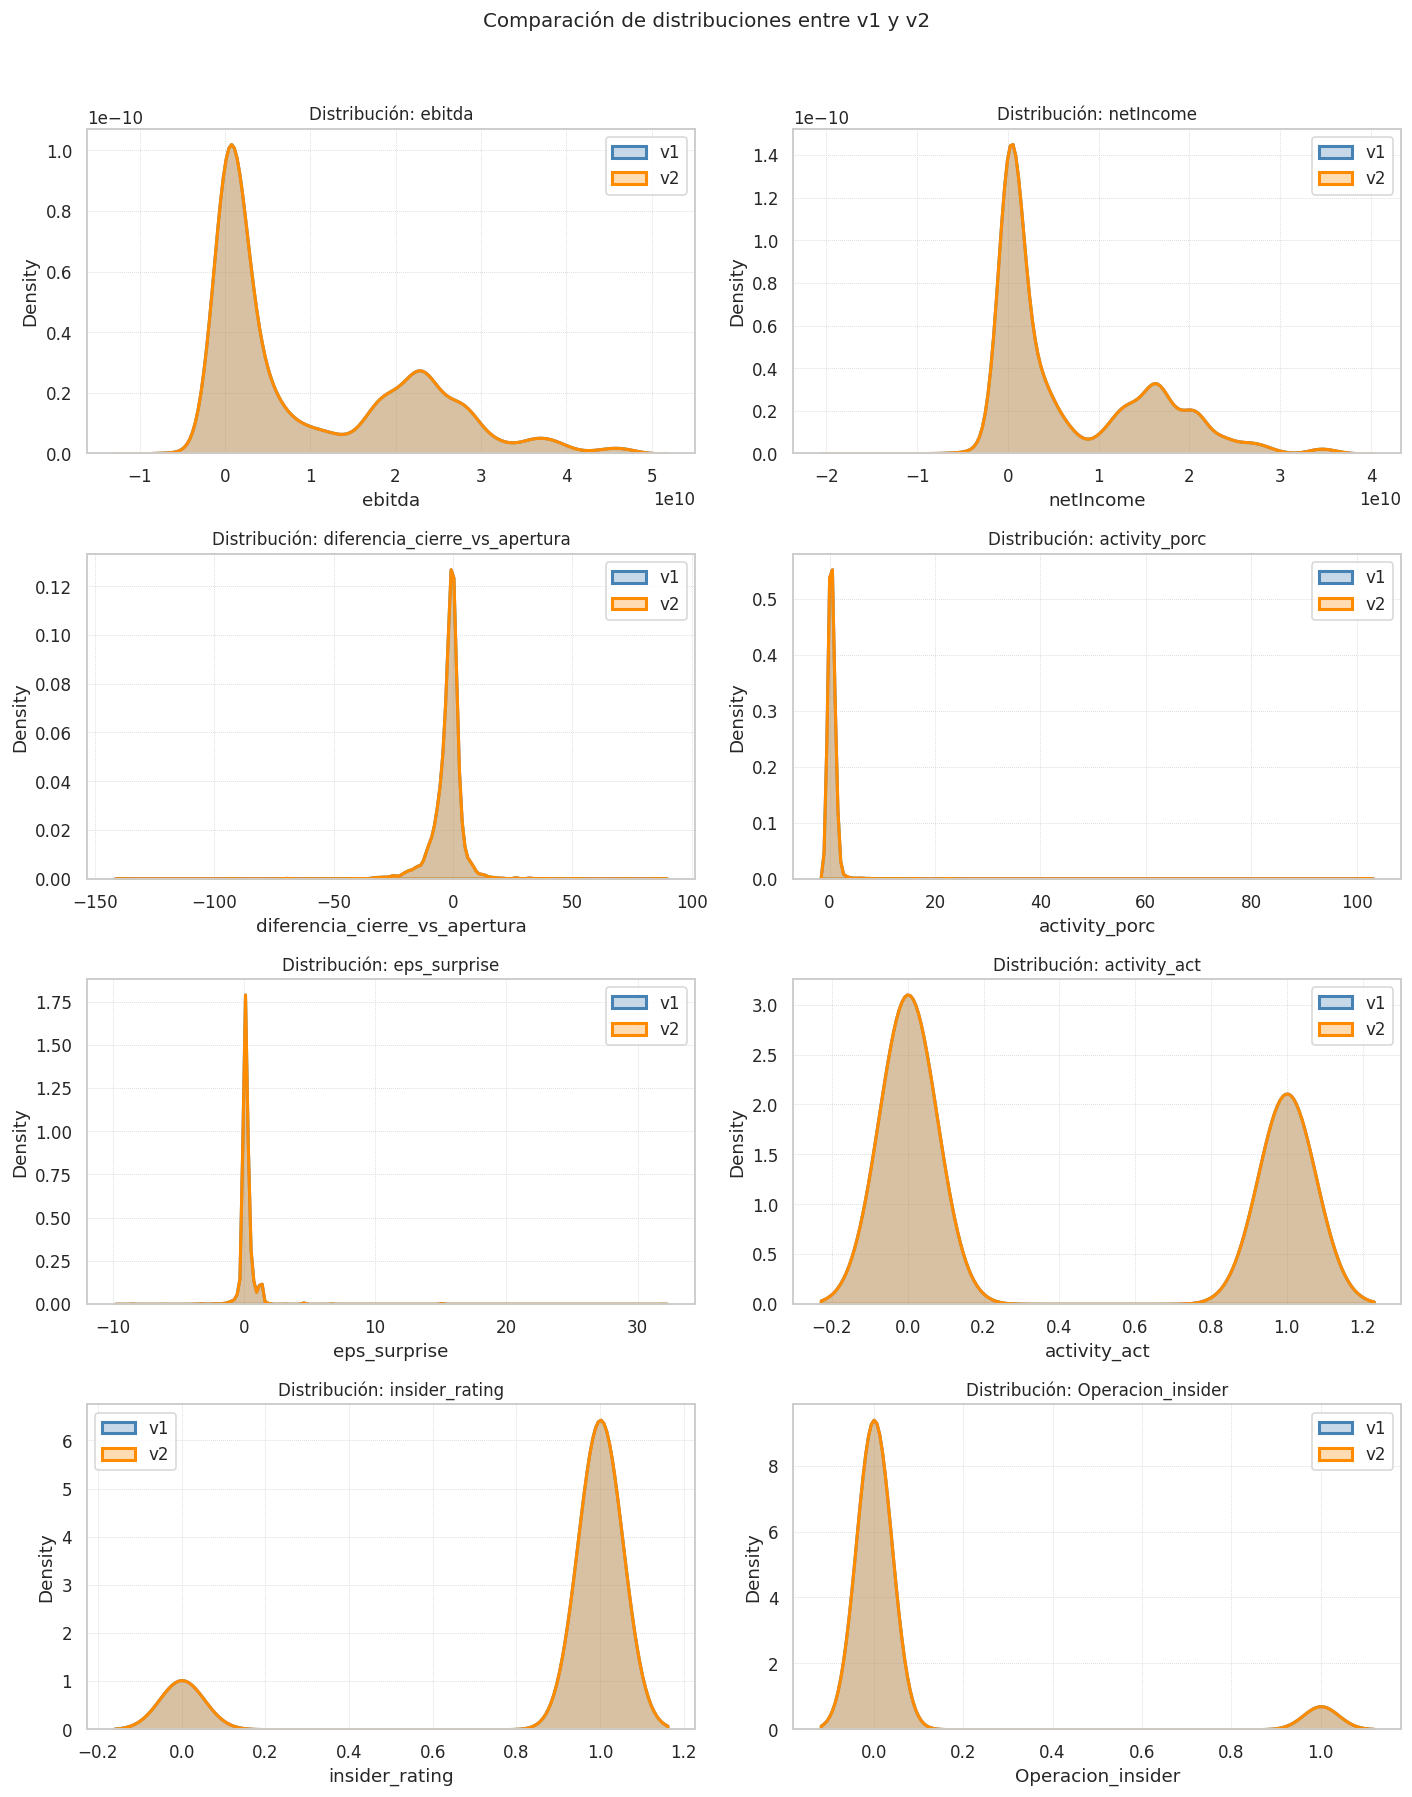

In [5]:
# ============================================
# Comparación de distribuciones v1 vs v2 (solo distribuciones)
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuración general ---
PATH_V1 = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep.csv"
PATH_V2 = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep_v2.csv"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# --- Carga de datos ---
v1 = pd.read_csv(PATH_V1)
v2 = pd.read_csv(PATH_V2)

# --- Identificar columnas numéricas comunes ---
numeric_common = sorted(set(v1.select_dtypes(include=[np.number]).columns) & 
                        set(v2.select_dtypes(include=[np.number]).columns))

if len(numeric_common) == 0:
    print("No hay columnas numéricas comunes para comparar distribuciones.")
else:
    # Seleccionar las 8 con mayor varianza combinada (para evitar plots redundantes)
    var_score = []
    for c in numeric_common:
        both = pd.concat([v1[c], v2[c]], axis=0).dropna()
        if len(both) > 0:
            var_score.append((c, both.var()))
    top_vars = [c for c, _ in sorted(var_score, key=lambda x: x[1], reverse=True)[:8]]

    # --- Visualización ---
    ncols = 2
    nrows = int(np.ceil(len(top_vars) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, top_vars):
        sns.kdeplot(v1[col].dropna(), ax=ax, color="steelblue", lw=2, label="v1", fill=True, alpha=0.3)
        sns.kdeplot(v2[col].dropna(), ax=ax, color="darkorange", lw=2, label="v2", fill=True, alpha=0.3)
        ax.set_title(f"Distribución: {col}", fontsize=11)
        ax.legend()
        ax.grid(True, linestyle=":", linewidth=0.5)
    for k in range(len(top_vars), len(axes)):
        axes[k].set_visible(False)

    fig.suptitle("Comparación de distribuciones entre v1 y v2", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_1458830/1625080618.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1458830/1625080618.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1458830/1625080618.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1458830/1625080618.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1458830/1625080618.py:51: Fut

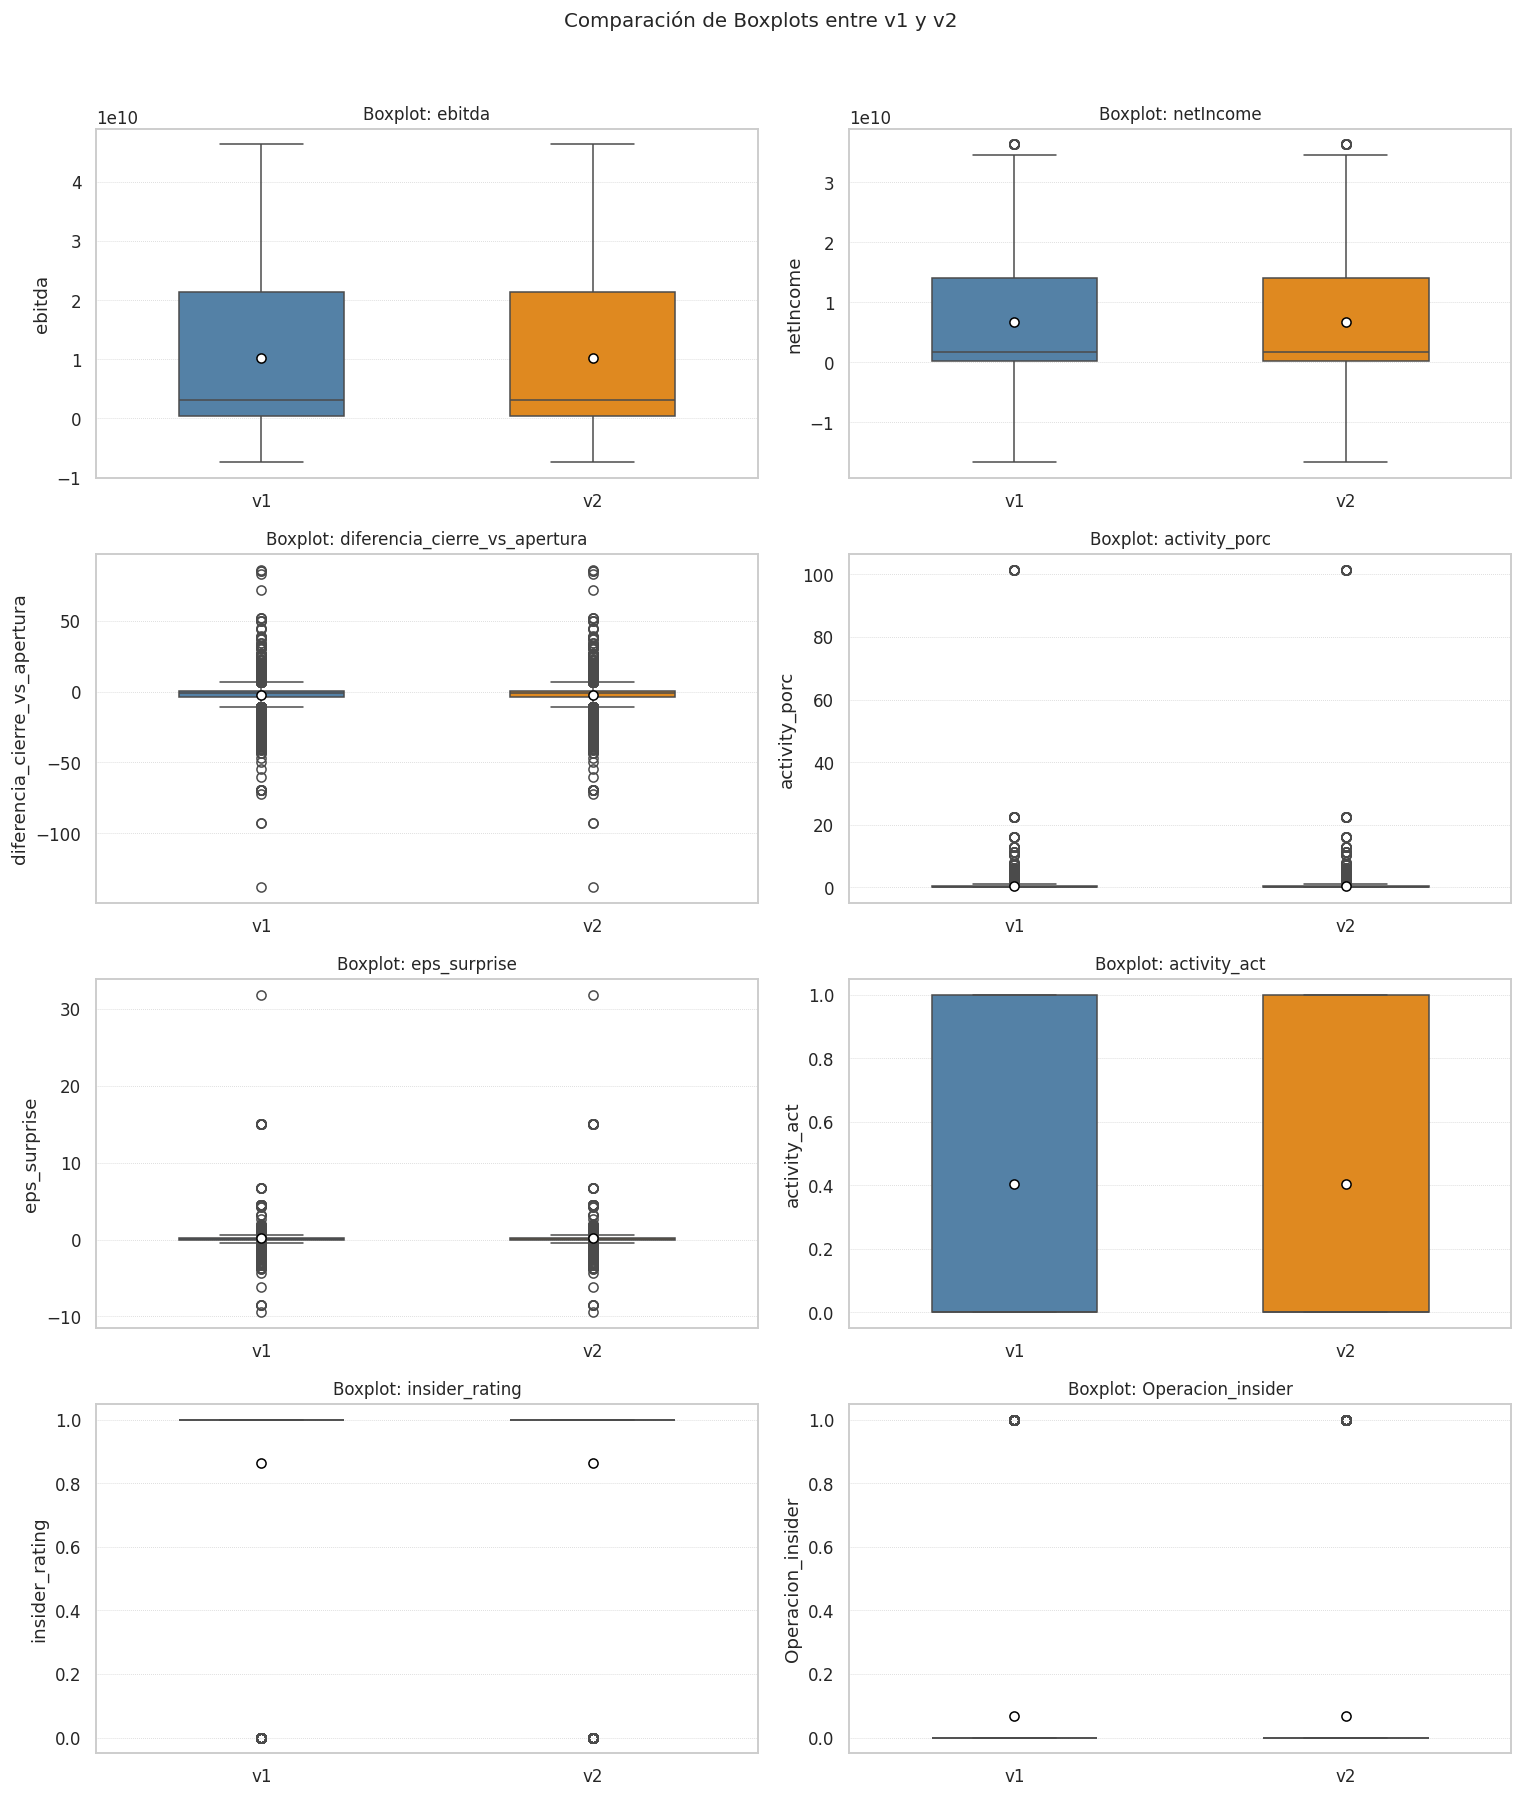

In [7]:
# ============================================
# Boxplots comparativos v1 vs v2
# ============================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Configuración general ---
PATH_V1 = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep.csv"
PATH_V2 = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep_v2.csv"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# --- Carga ---
v1 = pd.read_csv(PATH_V1)
v2 = pd.read_csv(PATH_V2)

# --- Identificar columnas numéricas comunes ---
numeric_common = sorted(set(v1.select_dtypes(include=[np.number]).columns) & 
                        set(v2.select_dtypes(include=[np.number]).columns))

if len(numeric_common) == 0:
    print("No hay columnas numéricas comunes para comparar boxplots.")
else:
    # Seleccionar hasta 8 con mayor varianza combinada
    var_score = []
    for c in numeric_common:
        both = pd.concat([v1[c], v2[c]], axis=0).dropna()
        if len(both) > 0:
            var_score.append((c, both.var()))
    top_vars = [c for c, _ in sorted(var_score, key=lambda x: x[1], reverse=True)[:8]]

    # Preparar dataframe combinado
    v1_ = v1[top_vars].copy()
    v1_["dataset"] = "v1"
    v2_ = v2[top_vars].copy()
    v2_["dataset"] = "v2"
    combined = pd.concat([v1_, v2_], axis=0, ignore_index=True)

    # --- Visualización ---
    ncols = 2
    nrows = int(np.ceil(len(top_vars) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    palette = {"v1": "steelblue", "v2": "darkorange"}

    for ax, col in zip(axes, top_vars):
        sns.boxplot(
            data=combined,
            x="dataset",
            y=col,
            ax=ax,
            palette=palette,
            showmeans=True,
            meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black"},
            width=0.5
        )
        ax.set_title(f"Boxplot: {col}", fontsize=11)
        ax.set_xlabel("")
        ax.grid(True, axis="y", linestyle=":", linewidth=0.5)

    for k in range(len(top_vars), len(axes)):
        axes[k].set_visible(False)

    fig.suptitle("Comparación de Boxplots entre v1 y v2", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


In [10]:

print("=== insider_rating en v1 ===")
if "insider_rating" in v1.columns:
    print(v1["insider_rating"].dropna().unique())
    print(f"Total únicos: {v1['insider_rating'].nunique(dropna=True)}")
else:
    print("La columna 'insider_rating' no existe en v1.")

print("\n=== insider_rating en v2 ===")
if "insider_rating" in v2.columns:
    print(v2["insider_rating"].dropna().unique())
    print(f"Total únicos: {v2['insider_rating'].nunique(dropna=True)}")
else:
    print("La columna 'insider_rating' no existe en v2.")


=== insider_rating en v1 ===
[1. 0.]
Total únicos: 2

=== insider_rating en v2 ===
[1. 0.]
Total únicos: 2


In [12]:
import pandas as pd

# === Rutas de tus datasets ===
PATH_V1 = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep.csv"
PATH_V2 = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep_v2.csv"

# === Leer datasets ===
v1 = pd.read_csv(PATH_V1)
v2 = pd.read_csv(PATH_V2)

# === Conversión a numérico (segura) ===
for name, df in {"v1": v1, "v2": v2}.items():
    if "insider_rating" in df.columns:
        df["insider_rating"] = (
            pd.to_numeric(
                df["insider_rating"]
                .astype(str)                # convertir a string por si hay mezclas
                .str.replace(",", ".", regex=False)  # reemplazar comas por puntos si existen
                .str.strip(),               # limpiar espacios
                errors="coerce"             # convertir no numéricos a NaN
            )
        )
        print(f"{name}: insider_rating convertido a numérico ({df['insider_rating'].dtype})")
        print(df["insider_rating"].unique()[:10])  # muestra primeros valores únicos


v1: insider_rating convertido a numérico (float64)
[1. 0.]
v2: insider_rating convertido a numérico (float64)
[1. 0.]


v1: insider_rating convertido a numérico (float64)
[1. 0.]
v2: insider_rating convertido a numérico (float64)
[1. 0.]


/tmp/ipykernel_1458830/498695301.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


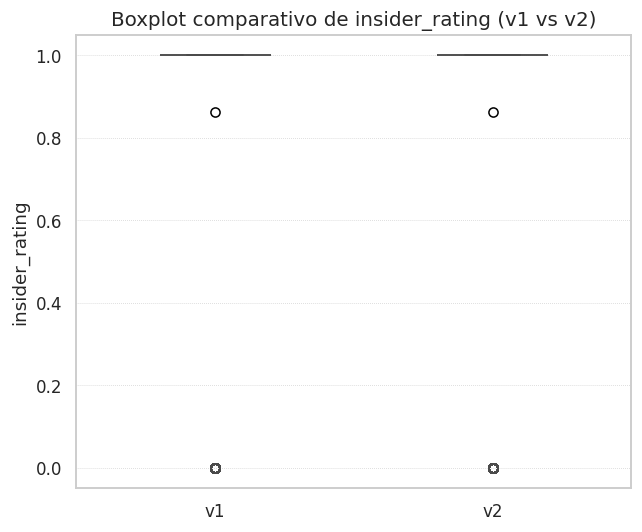

In [13]:
# ============================================
# Boxplot comparativo solo para insider_rating (ya convertido a numérico)
# ============================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Rutas ---
PATH_V1 = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep.csv"
PATH_V2 = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep_v2.csv"

# --- Leer datasets ---
v1 = pd.read_csv(PATH_V1)
v2 = pd.read_csv(PATH_V2)

# --- Convertir insider_rating a numérico seguro ---
for name, df in {"v1": v1, "v2": v2}.items():
    if "insider_rating" in df.columns:
        df["insider_rating"] = (
            pd.to_numeric(
                df["insider_rating"]
                .astype(str)
                .str.replace(",", ".", regex=False)
                .str.strip(),
                errors="coerce"
            )
        )
        print(f"{name}: insider_rating convertido a numérico ({df['insider_rating'].dtype})")
        print(df["insider_rating"].unique()[:10])

# --- Preparar data combinada ---
v1_ = v1[["insider_rating"]].copy()
v1_["dataset"] = "v1"
v2_ = v2[["insider_rating"]].copy()
v2_["dataset"] = "v2"
combined = pd.concat([v1_, v2_], ignore_index=True)

# --- Boxplot ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 5))
palette = {"v1": "steelblue", "v2": "darkorange"}

sns.boxplot(
    data=combined,
    x="dataset",
    y="insider_rating",
    palette=palette,
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black"},
    width=0.4
)

plt.title("Boxplot comparativo de insider_rating (v1 vs v2)", fontsize=13)
plt.ylabel("insider_rating")
plt.xlabel("")
plt.grid(True, axis="y", linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()


In [14]:
# Verificación binaria
for name, df in {"v1": v1, "v2": v2}.items():
    if "insider_rating" in df.columns:
        uniques = sorted(df["insider_rating"].dropna().unique())
        print(f"{name}: valores únicos = {uniques}")
        if all(val in [0,1] for val in uniques):
            print(f"✅ {name}: insider_rating es estrictamente binaria.\n")
        else:
            print(f"⚠️ {name}: contiene valores fuera de 0 y 1.\n")


v1: valores únicos = [np.float64(0.0), np.float64(1.0)]
✅ v1: insider_rating es estrictamente binaria.

v2: valores únicos = [np.float64(0.0), np.float64(1.0)]
✅ v2: insider_rating es estrictamente binaria.



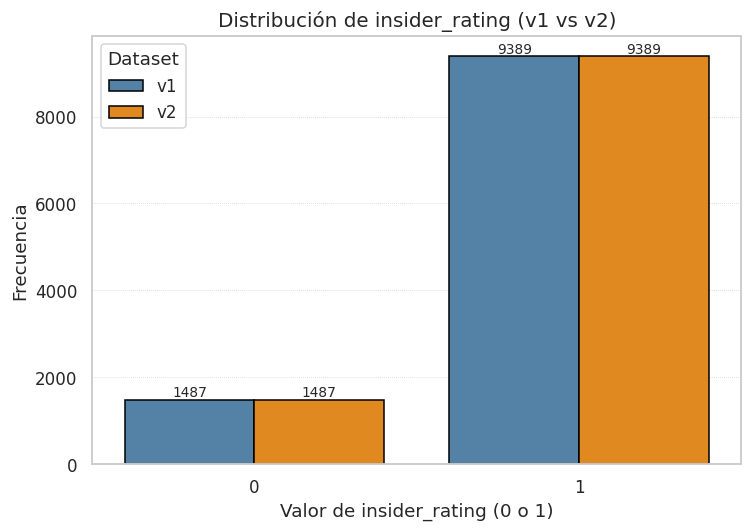

In [15]:
# ============================================
# Countplot comparativo de insider_rating (v1 vs v2)
# ============================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Rutas ---
PATH_V1 = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep.csv"
PATH_V2 = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep_v2.csv"

# --- Leer datasets ---
v1 = pd.read_csv(PATH_V1)
v2 = pd.read_csv(PATH_V2)

# --- Conversión segura a numérico ---
for name, df in {"v1": v1, "v2": v2}.items():
    if "insider_rating" in df.columns:
        df["insider_rating"] = (
            pd.to_numeric(
                df["insider_rating"]
                .astype(str)
                .str.replace(",", ".", regex=False)
                .str.strip(),
                errors="coerce"
            )
        )
        # Reforzar binario
        df["insider_rating"] = (df["insider_rating"] >= 0.5).astype(int)

# --- Combinar datasets ---
v1_ = v1[["insider_rating"]].copy()
v1_["dataset"] = "v1"
v2_ = v2[["insider_rating"]].copy()
v2_["dataset"] = "v2"
combined = pd.concat([v1_, v2_], ignore_index=True)

# --- Countplot ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7,5))
palette = {"v1": "steelblue", "v2": "darkorange"}

ax = sns.countplot(
    data=combined,
    x="insider_rating",
    hue="dataset",
    palette=palette,
    edgecolor="black"
)

# Etiquetas de conteo sobre cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%d", label_type="edge", fontsize=9)

plt.title("Distribución de insider_rating (v1 vs v2)", fontsize=13)
plt.xlabel("Valor de insider_rating (0 o 1)")
plt.ylabel("Frecuencia")
plt.legend(title="Dataset")
plt.grid(True, axis="y", linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()
